In [1]:
## Load pacakges
import os
import re
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.stats import binned_statistic
import networkx as nx
from itertools import combinations
import networkx as nx
import warnings
import xarray as xr
from scipy import sparse

/jp_envs/envs/scanpy/lib/python3.12/site-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/jp_envs/envs/scanpy/lib/python3.12/site-packages/leidenalg/VertexPartition.py:788: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\sum_{ij} \\left(A_{ij} - \\gamma \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/jp_envs/envs/scanpy/lib/python3.12/site-packages/leidenalg/Optimiser.py:27: SyntaxWarning: invalid escape sequence '\g'
  implementation therefore does not guarantee subpartition :math:`\gamma`-density.
/jp_envs/envs/scanpy/lib/python3.12/site-packages/leidenalg/Optimiser.py:346: SyntaxWarning: invalid escape sequence '\s'
  .. math:: Q = \sum_k \\lambda_k Q_k.


In [4]:
## Define helper functions
def compute_window_hypo_fraction(chr_matrix, window_size, step):

    n_bins = chr_matrix.shape[1]
    results = []

    for start in range(0, n_bins - window_size + 1, step):
        end = start + window_size
        window = chr_matrix[:, start:end]

        valid_mask = window >= 0
        valid_counts = valid_mask.sum(axis=1)

        hypo_counts = (window > 0).sum(axis=1)

        frac = np.zeros(window.shape[0])
        nonzero = valid_counts > 0
        frac[nonzero] = hypo_counts[nonzero] / valid_counts[nonzero]

        results.append(frac)

    return np.vstack(results).T  # cells × windows

def merge_intervals(intervals):
    if not intervals:
        return []

    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [intervals[0]]

    for current in intervals[1:]:
        prev = merged[-1]

        if current[0] <= prev[1]:  # overlap
            merged[-1] = (prev[0], max(prev[1], current[1]))
        else:
            merged.append(current)

    return merged


def call_hypo_domains(
    adata,
    cell_ids,
    window_size=5,
    step=1,
    hypo_threshold=0.6,
    min_bins=13,          # ~250kb
    bin_size_bp=20000
):

    valid_cells = [c for c in cell_ids if c in adata.obs_names]
    row_idx = [adata.obs_names.get_loc(c) for c in valid_cells]
    X = adata.layers['imputed'][row_idx, :].copy()

    X = X.toarray()

    chroms = []
    bins = []

    for name in adata.var_names:
        chrom, bin_id = name.split("_")
        chroms.append(chrom)
        bins.append(int(bin_id))

    df_bins = pd.DataFrame({
        "chrom": chroms,
        "bin": bins,
        "col_index": np.arange(len(bins))
    })

    all_domains = []

    for chrom, sub_df in df_bins.groupby("chrom"):

        sub_df = sub_df.sort_values("bin")

        cols = sub_df["col_index"].values
        bin_ids = sub_df["bin"].values

        chr_matrix = X[:, cols]

        frac_matrix = compute_window_hypo_fraction(
            chr_matrix,
            window_size,
            step
        )

        n_windows = frac_matrix.shape[1]

        mean_frac = frac_matrix.mean(axis=0)
        hypo_windows = np.where(mean_frac >= hypo_threshold)[0]

        if len(hypo_windows) == 0:
            continue

        intervals = []
        for w in hypo_windows:
            start_col = w
            end_col = min(w + window_size - 1, chr_matrix.shape[1] - 1)  # clip to last column
            intervals.append((start_col, end_col))
        merged_cols = merge_intervals(intervals)

        for start_col, end_col in merged_cols:
            length_bins = end_col - start_col + 1
            if length_bins >= min_bins:
                domain_matrix = chr_matrix[:, start_col:end_col + 1]
                domain_matrix = np.where(domain_matrix == -1, np.nan, domain_matrix)
                mean_meth = np.nanmean(domain_matrix)
                start_bin = bin_ids[start_col]
                end_bin = bin_ids[end_col]
        
                all_domains.append({
                    "chrom": chrom,
                    "start_bin": start_bin,
                    "end_bin": end_bin,
                    "start_bp": start_bin * bin_size_bp,
                    "end_bp": (end_bin + 1) * bin_size_bp,
                    "length_bins": length_bins,
                    "length_bp": length_bins * bin_size_bp,
                    "mean_methylation": mean_meth
                })
        
    return pd.DataFrame(all_domains)

def reciprocal_overlap(a_start, a_end, b_start, b_end):
    """Return reciprocal overlap fraction."""
    overlap = max(0, min(a_end, b_end) - max(a_start, b_start))
    if overlap == 0:
        return 0
    a_len = a_end - a_start
    b_len = b_end - b_start
    return min(overlap / a_len, overlap / b_len)


In [ ]:
## step 1. annotate all PMD at sample level
all_domains = []
celltype_meta = pd.read_csv("../input_metadata/cell_meta.tsv", sep="\t")
sample_df = pd.read_csv("../input_metadata/sample_data.txt", sep="\t")
sample_df = sample_df[["id", "Group"]]

for sample_id in celltype_meta["id"].unique():
    adata = sc.read_h5ad(f"tmp_dataset/methy_matrix_impute/{sample_id}_methy_imputed.h5ad") ### set this to directory where PRIME-IMPUTE h5ad matrix are present

    # get LE cells for this sample
    le_cells = celltype_meta.index[
        (celltype_meta["id"] == sample_id) & (celltype_meta["epi_cl"] == "LE")
    ].tolist()
    
    le_cells = [c for c in le_cells if c in adata.obs_names]
    
    if len(le_cells) == 0:
        continue  # skip if no LE cells in this sample
    
    domains = call_hypo_domains(
        adata,
        cell_ids=le_cells,
        window_size=5,
        step=1,
        hypo_threshold=0.6,
        min_bins=13
    )
    
    if not domains.empty:
        domains["sample_id"] = sample_id
        all_domains.append(domains)

all_domains_df = pd.concat(all_domains, ignore_index=True)

print(all_domains_df.head())

all_domains_df_lf = all_domains_df.merge(
    sample_df,
    on="id",
    how="left"
)
all_domains_df_lf
all_domains_df_lf["Group"].value_counts()

all_domains_df = all_domains_df.reset_index(drop=True)
all_domains_df['pmd_id'] = all_domains_df['id'] + "_PMD" + all_domains_df.index.astype(str)
all_domains_df.to_csv("tmp_dataset/all_PMDs.tsv", sep="\t", index=False)


In [49]:
## find ovalapping PMDs across samples
df = all_domains_df.copy()
overlap_dict = {}
for chrom, subdf in df.groupby('chrom'):
    subdf = subdf.reset_index(drop=True)
    n = len(subdf)    
    for i in range(n):
        for j in range(i+1, n):
            # skip same sample
            if subdf.loc[i, 'id'] == subdf.loc[j, 'id']:
                continue
            
            ro = reciprocal_overlap(
                subdf.loc[i, 'start_bp'], subdf.loc[i, 'end_bp'],
                subdf.loc[j, 'start_bp'], subdf.loc[j, 'end_bp']
            )
            
            if ro >= 0.7:
                overlap_dict[(subdf.loc[i, 'pmd_id'], subdf.loc[j, 'pmd_id'])] = 1
                overlap_dict[(subdf.loc[j, 'pmd_id'], subdf.loc[i, 'pmd_id'])] = 1

pmd_ids = df['pmd_id'].tolist()
n = len(pmd_ids)
overlap_matrix = np.zeros((n, n), dtype=int)

id_to_idx = {pid: i for i, pid in enumerate(pmd_ids)}
for (pid1, pid2), val in overlap_dict.items():
    i = id_to_idx[pid1]
    j = id_to_idx[pid2]
    overlap_matrix[i, j] = val
np.fill_diagonal(overlap_matrix, 0)
overlap_df_matrix = pd.DataFrame(overlap_matrix, index=pmd_ids, columns=pmd_ids)


G = nx.from_pandas_adjacency(overlap_df_matrix)
components = list(nx.connected_components(G))

pmd_to_component_safe = {}

for comp_id, comp in enumerate(components, 1):
    for pmd in comp:
        pmd_to_component_safe[pmd] = comp_id

all_pmids = set(all_domains_df["pmd_id"])
isolated_pmids = all_pmids - set(pmd_to_component_safe.keys())

next_comp_id = len(components) + 1
for pmd in isolated_pmids:
    pmd_to_component_safe[pmd] = next_comp_id
    next_comp_id += 1

all_domains_df["collapsed_pmd_id"] = all_domains_df["pmd_id"].map(
    lambda x: f"PMD_{pmd_to_component_safe[x]}"
)

all_domains_df["collapsed_pmd_id"].str[:4].value_counts()

all_domains_df.groupby("collapsed_pmd_id")["id"].nunique()

### PMDs collapsed at cross-sample level
all_domains_df.to_csv("tmp_dataset/all_PMDs_collapsed.tsv", sep="\t", index=False)

In [30]:
## iteratively merging smaller PMDs into larger containing PMDs
all_domains_df = pd.read_csv("tmp_dataset/all_PMDs_collapsed.tsv", sep="\t")
overlap_threshold = 0.8
all_domains_df["collapsed_pmd_id_nest"] = all_domains_df["collapsed_pmd_id"]
all_domains_df["is_nested"] = False
all_domains_df["pmd_length"] = all_domains_df["end_bp"] - all_domains_df["start_bp"]

iteration = 0
prev_unique_count = all_domains_df["collapsed_pmd_id_nest"].nunique()
stabilized_count_flag = False
max_iterations = 20  # safety limit

while not stabilized_count_flag and iteration < max_iterations:
    iteration += 1
    print(f"Iteration {iteration}...")

    prev_assignments = all_domains_df["collapsed_pmd_id_nest"].copy()

    collapsed_spans = (
        all_domains_df.groupby("collapsed_pmd_id_nest")
        .agg(chrom=("chrom", "first"),
             start_bp=("start_bp", "min"),
             end_bp=("end_bp", "max"))
        .reset_index()
    )
    collapsed_spans["length"] = collapsed_spans["end_bp"] - collapsed_spans["start_bp"]
    collapsed_spans = collapsed_spans.sort_values("length", ascending=False)  # larger first

    nested_mapping = {}

    for idx, row in all_domains_df.iterrows():
        chrom = row["chrom"]
        start = row["start_bp"]
        end = row["end_bp"]
        length = row["pmd_length"]
        current_pmd = row["collapsed_pmd_id_nest"]

        # Candidates: larger collapsed PMDs on same chromosome
        candidates = collapsed_spans[
            (collapsed_spans["chrom"] == chrom) &
            (collapsed_spans["collapsed_pmd_id_nest"] != current_pmd) &
            (collapsed_spans["length"] > length)
        ]

        for _, cpm in candidates.iterrows():
            overlap_len = max(0, min(end, cpm["end_bp"]) - max(start, cpm["start_bp"]))
            frac = overlap_len / length
            if frac >= overlap_threshold:
                nested_mapping[row["pmd_id"]] = cpm["collapsed_pmd_id_nest"]
                break

    all_domains_df["collapsed_pmd_id_nest"] = all_domains_df["pmd_id"].map(
        lambda x: nested_mapping.get(x, all_domains_df.loc[all_domains_df["pmd_id"]==x, "collapsed_pmd_id_nest"].values[0])
    )

    all_domains_df["is_nested"] = all_domains_df["pmd_id"].isin(nested_mapping.keys())

    current_unique_count = all_domains_df["collapsed_pmd_id_nest"].nunique()
    print(f"Unique collapsed_pmd_id_nest after iteration {iteration}: {current_unique_count}")

    if current_unique_count == prev_unique_count:
        stabilized_count_flag = True
        print(f"Unique ID count stabilized at {current_unique_count}. Stopping iterations.")
    else:
        prev_unique_count = current_unique_count

num_before = all_domains_df["collapsed_pmd_id"].nunique()
nested_count = all_domains_df["is_nested"].sum()
num_after = all_domains_df["collapsed_pmd_id_nest"].nunique()
reduction = num_before - num_after

print("\n--- PMD Nesting Summary ---")
print(f"Number of collapsed PMDs before nesting: {num_before}")
print(f"Number of PMDs nested into larger PMDs: {nested_count}")
print(f"Number of collapsed PMDs after nesting: {num_after}")
print(f"Reduction in collapsed PMDs: {reduction}")

all_domains_df.to_csv("tmp_dataset/all_PMDs_collapsed_nested.tsv", sep="\t", index=False)

Iteration 1...
Unique collapsed_pmd_id_nest after iteration 1: 1355
Iteration 2...
Unique collapsed_pmd_id_nest after iteration 2: 1351
Iteration 3...
Unique collapsed_pmd_id_nest after iteration 3: 1341
Iteration 4...
Unique collapsed_pmd_id_nest after iteration 4: 1339
Iteration 5...
Unique collapsed_pmd_id_nest after iteration 5: 1338
Iteration 6...
Unique collapsed_pmd_id_nest after iteration 6: 1338
Unique ID count stabilized at 1338. Stopping iterations.

--- PMD Nesting Summary ---
Number of collapsed PMDs before nesting: 3231
Number of PMDs nested into larger PMDs: 301
Number of collapsed PMDs after nesting: 1338
Reduction in collapsed PMDs: 1893


In [33]:
## summarize PMDs across samples
collapsed_summary = all_domains_df.groupby("collapsed_pmd_id_nest").agg(
    chrom=("chrom", "first"),  
    start_bp=("start_bp", "min"),
    end_bp=("end_bp", "max"),
    num_samples=("sample_id", "nunique"), 
    num_pmids=("pmd_id", "count"),        
    num_nested=("is_nested", "sum")        
).reset_index()

# Optional: sort by chromosome and start
collapsed_summary = collapsed_summary.sort_values(["chrom", "start_bp"]).reset_index(drop=True)
collapsed_summary.head()
collapsed_summary.to_csv("tmp_dataset/PMDs_list_start_end.tsv", sep="\t", index=False)

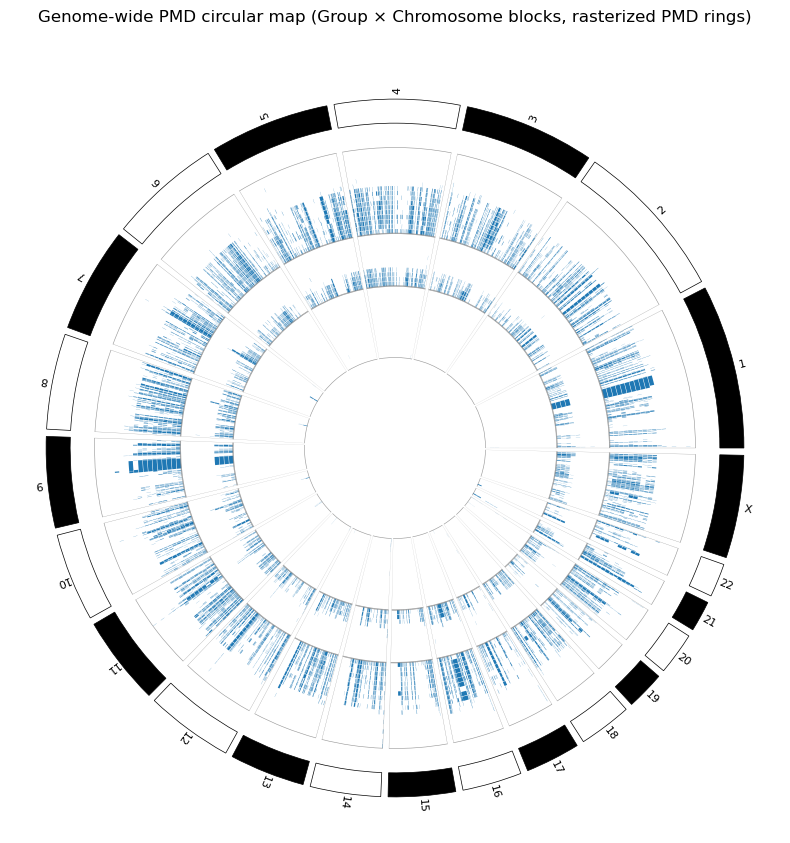

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

domains = all_domains_df.copy()
domains["start_bp"] = pd.to_numeric(domains["start_bp"])
domains["end_bp"] = pd.to_numeric(domains["end_bp"])

sample_info = pd.read_csv("../input_metadata/sample_data.txt", sep="\t")  # must have sample_id and Group
domains = domains.merge(sample_info, on="sample_id", how="right")  # keep all samples

# -----------------------------
# 1b. Compute PMD coverage per sample
# -----------------------------
domains["pmd_length"] = domains["end_bp"] - domains["start_bp"]
pmd_coverage = domains.groupby("id")["pmd_length"].sum().reset_index()
pmd_coverage.rename(columns={"pmd_length": "PMD_coverage"}, inplace=True)
sample_info = sample_info.merge(pmd_coverage, on="id", how="left")
sample_info["PMD_coverage"] = sample_info["PMD_coverage"].fillna(0)

hg38_lengths = {
    "chr1": 248956422, "chr2": 242193529, "chr3": 198295559, "chr4": 190214555,
    "chr5": 181538259, "chr6": 170805979, "chr7": 159345973, "chr8": 145138636,
    "chr9": 138394717, "chr10": 133797422, "chr11": 135086622, "chr12": 133275309,
    "chr13": 114364328, "chr14": 107043718, "chr15": 101991189, "chr16": 90338345,
    "chr17": 83257441, "chr18": 80373285, "chr19": 58617616, "chr20": 64444167,
    "chr21": 46709983, "chr22": 50818468, "chrX": 156040895, "chrY": 57227415
}

chrom_order = [c for c in [f"chr{i}" for i in range(1,23)] + ["chrX","chrY"] if c in domains["chrom"].dropna().unique()]
chrom_lengths = {c: hg38_lengths[c] for c in chrom_order}

gap = np.deg2rad(1.2)
total_gap = gap * len(chrom_order)
genome_length = sum(chrom_lengths.values())
usable_angle = 2 * np.pi - total_gap

chrom_angles = {}
start_angle = 0
for chrom in chrom_order:
    frac = chrom_lengths[chrom] / genome_length
    angle = frac * usable_angle
    chrom_angles[chrom] = (start_angle, start_angle + angle)
    start_angle += angle + gap

sample_info_sorted = sample_info.sort_values(["Group", "PMD_coverage"], ascending=[True, False])
samples = sample_info_sorted["id"].tolist()
sample_to_group = sample_info_sorted.set_index("id")["Group"].to_dict()

inner_r = 0.3
outer_r = 1.0
n_samples = len(samples)
ring_width = (outer_r - inner_r) / n_samples

sample_bottoms = {}
group_sample_range = {}
for grp in sample_info_sorted["Group"].unique():
    grp_samples = sample_info_sorted[sample_info_sorted["Group"]==grp]["id"].tolist()
    r_start = inner_r + samples.index(grp_samples[0]) * ring_width
    r_end = inner_r + (samples.index(grp_samples[-1]) + 1) * ring_width
    group_sample_range[grp] = (r_start, r_end)
    for s in grp_samples:
        sample_bottoms[s] = inner_r + samples.index(s) * ring_width

fig = plt.figure(figsize=(10,10))
ax = plt.subplot(111, polar=True)
ax.grid(False)
ax.spines['polar'].set_visible(False)
ax.set_yticklabels([])
ax.set_xticklabels([])

for s in samples:
    sample_df = domains[domains["id"] == s]
    r_bottom = sample_bottoms[s]

    if not sample_df.dropna(subset=["chrom"]).empty:
        for _, row in sample_df.iterrows():
            chrom = row["chrom"]
            start_bp = row["start_bp"]
            end_bp = row["end_bp"]

            chrom_start, chrom_end = chrom_angles[chrom]
            chrom_len = chrom_lengths[chrom]

            theta_start = chrom_start + (start_bp/chrom_len)*(chrom_end-chrom_start)
            theta_end   = chrom_start + (end_bp/chrom_len)*(chrom_end-chrom_start)

            ax.bar(
                x=(theta_start+theta_end)/2,
                width=theta_end-theta_start,
                height=ring_width*0.9,
                bottom=r_bottom,
                color="#1F78B4",
                alpha=1.0,  # fully opaque
                rasterized=True
            )
    else:
        # placeholder for empty samples (white)
        ax.bar(
            x=0,
            width=2*np.pi,
            height=0,
            bottom=r_bottom,
            color="white",
            alpha=0,
            rasterized=True
        )

border_width = 0.002
for grp, (r_start, r_end) in group_sample_range.items():
    for chrom in chrom_order:
        chrom_start, chrom_end = chrom_angles[chrom]
        # bottom border
        ax.bar(
            x=(chrom_start+chrom_end)/2,
            width=chrom_end-chrom_start,
            height=border_width,
            bottom=r_start,
            color="grey",
            alpha=0.8
        )
        # top border
        ax.bar(
            x=(chrom_start+chrom_end)/2,
            width=chrom_end-chrom_start,
            height=border_width,
            bottom=r_end - border_width,
            color="grey",
            alpha=0.8
        )
        # left vertical line
        ax.bar(
            x=chrom_start,
            width=0.001,
            height=r_end-r_start,
            bottom=r_start,
            color="grey",
            alpha=0.8
        )
        # right vertical line
        ax.bar(
            x=chrom_end,
            width=0.001,
            height=r_end-r_start,
            bottom=r_start,
            color="grey",
            alpha=0.8
        )

chr_inner = outer_r + 0.08
chr_height = 0.08
for i, chrom in enumerate(chrom_order):
    start, end = chrom_angles[chrom]
    color = "black" if i % 2 == 0 else "white"
    ax.bar(
        x=(start+end)/2,
        width=end-start,
        height=chr_height,
        bottom=chr_inner,
        color=color,
        edgecolor="black",
        linewidth=.5
    )

for chrom in chrom_order:
    start, end = chrom_angles[chrom]
    angle = (start + end)/2
    ax.text(
        angle,
        chr_inner + chr_height + 0.03,
        chrom.replace("chr",""),
        ha="center",
        va="center",
        fontsize=8,
        rotation=np.degrees(angle),
        rotation_mode="anchor"
    )
plt.rcParams['pdf.fonttype'] = 42
ax.set_ylim(0, chr_inner + chr_height + 0.12)
plt.title("Genome-wide PMD circular map (Group × Chromosome blocks, rasterized PMD rings)", pad=30)

plt.savefig("figures/PMD_genome_circular_raster.svg", bbox_inches="tight", dpi=600)
plt.show()